Actual results:    [1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 1 1
 1 1 1 1 0 1 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1]
Predicted results: [1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1]

Accuracy: 91.67%

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      0.79      0.88        24
      Placed       0.88      1.00      0.94        36

    accuracy                           0.92        60
   macro avg       0.94      0.90      0.91        60
weighted avg       0.93      0.92      0.91        60

Confusion Matrix:
[[19  5]
 [ 0 36]]


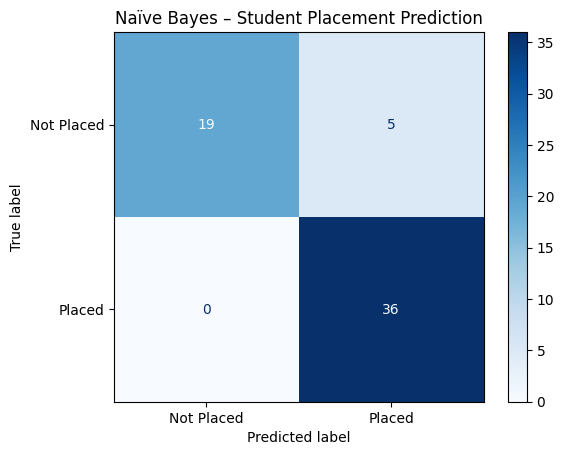

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Create sample dataset (Skip this block if you already have a loaded DataFrame 'df')
np.random.seed(42)
n_samples = 200
data = {
    "Study_Hours": np.random.uniform(1, 10, n_samples),
    "Attendance": np.random.uniform(50, 100, n_samples),
    "Project_Done": np.random.choice([0, 1], size=n_samples),
}
# Target logic: higher hours, attendance, and projects increase placement chances
data["Placed"] = (
    (data["Study_Hours"] * 0.4 + data["Attendance"] * 0.05 + data["Project_Done"] * 2) > 6.5
).astype(int)

df = pd.DataFrame(data)

# 1. Feature selection (Input/Output)
X = df[["Study_Hours", "Attendance", "Project_Done"]]
y = df["Placed"]

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3. Model Initialization & Training
model = GaussianNB()
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)

# 5. Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Actual results:   ", y_test.to_numpy())
print("Predicted results:", y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"],
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 6. Plot Confusion Matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Not Placed", "Placed"]
)

display.plot(cmap="Blues")
plt.title("Naïve Bayes – Student Placement Prediction")
plt.show()